# Airline Passenger Satisfaction — GA + GridSearch

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from warnings import filterwarnings
import random
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score,roc_auc_score
filterwarnings("ignore")

## 1. Veri Yükleme ve Ön İşleme

In [2]:
train_data=pd.read_csv(r"C:\Users\yigit\OneDrive\Masaüstü\yapayzeka\data\train.csv")
test_data=pd.read_csv(r"C:\Users\yigit\OneDrive\Masaüstü\yapayzeka\data\test.csv")
all_data=pd.concat((train_data.loc[:,"Gender":"satisfaction"],
                    test_data.loc[:,"Gender":"satisfaction"]))

In [3]:
all_data.isnull().sum()

Gender                                 0
Customer Type                          0
Age                                    0
Type of Travel                         0
Class                                  0
Flight Distance                        0
Inflight wifi service                  0
Departure/Arrival time convenient      0
Ease of Online booking                 0
Gate location                          0
Food and drink                         0
Online boarding                        0
Seat comfort                           0
Inflight entertainment                 0
On-board service                       0
Leg room service                       0
Baggage handling                       0
Checkin service                        0
Inflight service                       0
Cleanliness                            0
Departure Delay in Minutes             0
Arrival Delay in Minutes             393
satisfaction                           0
dtype: int64

In [4]:
all_data["Arrival Delay in Minutes"]=all_data["Arrival Delay in Minutes"].fillna(all_data["Arrival Delay in Minutes"].median())

In [5]:
all_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 129880 entries, 0 to 25975
Data columns (total 23 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   Gender                             129880 non-null  object 
 1   Customer Type                      129880 non-null  object 
 2   Age                                129880 non-null  int64  
 3   Type of Travel                     129880 non-null  object 
 4   Class                              129880 non-null  object 
 5   Flight Distance                    129880 non-null  int64  
 6   Inflight wifi service              129880 non-null  int64  
 7   Departure/Arrival time convenient  129880 non-null  int64  
 8   Ease of Online booking             129880 non-null  int64  
 9   Gate location                      129880 non-null  int64  
 10  Food and drink                     129880 non-null  int64  
 11  Online boarding                    129880 non

In [6]:
numeric_cols=all_data.select_dtypes(include=["int64","float64"]).columns
numeric_cols

Index(['Age', 'Flight Distance', 'Inflight wifi service',
       'Departure/Arrival time convenient', 'Ease of Online booking',
       'Gate location', 'Food and drink', 'Online boarding', 'Seat comfort',
       'Inflight entertainment', 'On-board service', 'Leg room service',
       'Baggage handling', 'Checkin service', 'Inflight service',
       'Cleanliness', 'Departure Delay in Minutes',
       'Arrival Delay in Minutes'],
      dtype='object')

In [7]:
categoric_cols=all_data.select_dtypes(include="object").columns
categoric_cols

Index(['Gender', 'Customer Type', 'Type of Travel', 'Class', 'satisfaction'], dtype='object')

In [8]:
all_data.head()

,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,3,1,...,5,4,3,4,4,5,5,25,18.0,neutral or dissatisfied
1,Male,disloyal Customer,25,Business travel,Business,235,3,2,3,3,...,1,1,5,3,1,4,1,1,6.0,neutral or dissatisfied
2,Female,Loyal Customer,26,Business travel,Business,1142,2,2,2,2,...,5,4,3,4,4,4,5,0,0.0,satisfied
3,Female,Loyal Customer,25,Business travel,Business,562,2,5,5,5,...,2,2,5,3,1,4,2,11,9.0,neutral or dissatisfied
4,Male,Loyal Customer,61,Business travel,Business,214,3,3,3,3,...,3,3,4,4,3,3,3,0,0.0,satisfied


In [9]:
from sklearn.preprocessing import LabelEncoder
label_encoder=LabelEncoder()
all_data["satisfaction"]=label_encoder.fit_transform(all_data["satisfaction"].str.strip())
print(all_data["satisfaction"].unique())
all_data.head()

[0 1]


,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,3,1,...,5,4,3,4,4,5,5,25,18.0,0
1,Male,disloyal Customer,25,Business travel,Business,235,3,2,3,3,...,1,1,5,3,1,4,1,1,6.0,0
2,Female,Loyal Customer,26,Business travel,Business,1142,2,2,2,2,...,5,4,3,4,4,4,5,0,0.0,1
3,Female,Loyal Customer,25,Business travel,Business,562,2,5,5,5,...,2,2,5,3,1,4,2,11,9.0,0
4,Male,Loyal Customer,61,Business travel,Business,214,3,3,3,3,...,3,3,4,4,3,3,3,0,0.0,1


In [10]:
columns=["Gender","Customer Type","Type of Travel","Class"]
for i in columns:
    all_data[i]=label_encoder.fit_transform(all_data[i].str.strip())
all_data.head()

,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,1,0,13,1,2,460,3,4,3,1,...,5,4,3,4,4,5,5,25,18.0,0
1,1,1,25,0,0,235,3,2,3,3,...,1,1,5,3,1,4,1,1,6.0,0
2,0,0,26,0,0,1142,2,2,2,2,...,5,4,3,4,4,4,5,0,0.0,1
3,0,0,25,0,0,562,2,5,5,5,...,2,2,5,3,1,4,2,11,9.0,0
4,1,0,61,0,0,214,3,3,3,3,...,3,3,4,4,3,3,3,0,0.0,1


In [11]:
from sklearn.preprocessing import MinMaxScaler
minmax_scaler=MinMaxScaler()
data_scaled=minmax_scaler.fit_transform(all_data)
data_scaled=pd.DataFrame(data_scaled,columns=all_data.columns)
data_scaled.head()

,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,1.0,0.0,0.076923,1.0,1.0,0.086632,0.6,0.8,0.6,0.2,...,1.0,0.8,0.6,0.75,0.8,1.0,1.0,0.015704,0.011364,0.0
1,1.0,1.0,0.230769,0.0,0.0,0.041195,0.6,0.4,0.6,0.6,...,0.2,0.2,1.0,0.50,0.2,0.8,0.2,0.000628,0.003788,0.0
2,0.0,0.0,0.243590,0.0,0.0,0.224354,0.4,0.4,0.4,0.4,...,1.0,0.8,0.6,0.75,0.8,0.8,1.0,0.000000,0.000000,1.0
3,0.0,0.0,0.230769,0.0,0.0,0.107229,0.4,1.0,1.0,1.0,...,0.4,0.4,1.0,0.50,0.2,0.8,0.4,0.006910,0.005682,0.0
4,1.0,0.0,0.692308,0.0,0.0,0.036955,0.6,0.6,0.6,0.6,...,0.6,0.6,0.8,0.75,0.6,0.6,0.6,0.000000,0.000000,1.0


In [12]:
X=data_scaled.drop("satisfaction",axis=1)
y=data_scaled["satisfaction"]
feature_names=X.columns

In [13]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=42)

## 2. Genetik Algoritma — Özellik Seçimi

**Kromozom:** Her gen = bir özellik (1: seçili, 0: seçili değil)

In [14]:
POP_SIZE=15
GENS=8
MUTATION_RATE=0.1

num_features=X_train.shape[1]

In [15]:
def create_indiviual():
    return [random.randint(0,1) for _ in range(num_features)]

In [16]:
def fitness(indiviual):
    selected=[i for i in range(len(indiviual)) if indiviual[i]==1]
    if len(selected)==0:
        return 0
    X_tr=X_train.iloc[:,selected]
    x_te=X_test.iloc[:,selected]

    model=RandomForestClassifier(n_estimators=50,max_depth=10,n_jobs=-1)
    model.fit(X_tr,y_train)

    probs=model.predict_proba(x_te)[:,1]
    return roc_auc_score(y_test,probs)

In [17]:
def selection(pop):
    k=3
    selected=random.sample(pop,k)
    selected=sorted(selected,key=lambda x:fitness(x),reverse=True)
    return selected[0]

In [18]:
def crossover(p1,p2):
    point=random.randint(1,num_features-1)
    return p1[:point]+p2[point:]

In [19]:
def mutation(ind):
    for i in range(len(ind)):
        if random.random()<MUTATION_RATE:
            ind[i]=1-ind[i]
    return ind

In [20]:
population=[create_indiviual() for _ in range(POP_SIZE)]

best_individual=None
best_score=0

for gen in range(GENS):
    new_pop=[]

    for _ in range(POP_SIZE):
        p1=selection(population)
        p2=selection(population)

        child=crossover(p1,p2)
        child=mutation(child)

        new_pop.append(child)
    
    population=new_pop

    for ind in population:
        score=fitness(ind)
        if score>best_score:
            best_score=score
            best_individual=ind
    
    print(f"Gen {gen+1} -Best Roc-Auc: {best_score:.4f}")

Gen 1 -Best Roc-Auc: 0.9848
Gen 2 -Best Roc-Auc: 0.9877
Gen 3 -Best Roc-Auc: 0.9888
Gen 4 -Best Roc-Auc: 0.9893
Gen 5 -Best Roc-Auc: 0.9896
Gen 6 -Best Roc-Auc: 0.9900
Gen 7 -Best Roc-Auc: 0.9901
Gen 8 -Best Roc-Auc: 0.9901


In [21]:
selected_features=[i for i in range(len(best_individual)) if best_individual[i]==1]
print("seçilen feature sayısı:",len(selected_features))
print("feaure isimleri:",feature_names[selected_features])

seçilen feature sayısı: 17
feaure isimleri: Index(['Customer Type', 'Age', 'Type of Travel', 'Class',
       'Inflight wifi service', 'Departure/Arrival time convenient',
       'Ease of Online booking', 'Food and drink', 'Online boarding',
       'Seat comfort', 'On-board service', 'Leg room service',
       'Baggage handling', 'Checkin service', 'Inflight service',
       'Cleanliness', 'Arrival Delay in Minutes'],
      dtype='object')


## 3. GridSearch — Hiperparametre Optimizasyonu

GA'nın bulduğu feature seti üzerinde RF hiperparametrelerini optimize et.

In [22]:
from sklearn.model_selection  import  GridSearchCV
param_grid={
    "n_estimators":[100,150],
    "max_depth":[None,10],
    "min_samples_split":[2,5]
}
X_tr=X_train.iloc[:,selected_features]
X_te=X_test.iloc[:,selected_features]

grid=GridSearchCV(
    RandomForestClassifier(),
    param_grid,
    cv=3,
    scoring="roc_auc",
    n_jobs=-1
)
grid.fit(X_tr,y_train)
best_model=grid.best_estimator_
print("best params:",grid.best_params_)


best params: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 150}


## 4. Model Değerlendirme (Test Seti)

In [23]:
preds=best_model.predict(X_te)
probs=best_model.predict_proba(X_te)[:,1]

acc=accuracy_score(y_test,preds)
roc=roc_auc_score(y_test,probs)

print("accuracy:",acc)
print("roc auc:",roc)

accuracy: 0.9624268555589776
roc auc: 0.993879882103857


Text(0.5, 1.0, 'confussion matrix')

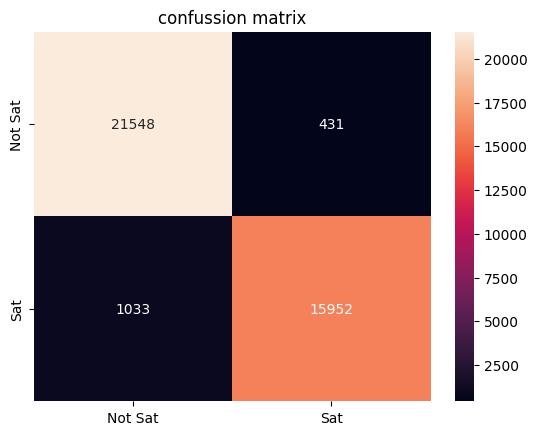

In [24]:
from sklearn.metrics import confusion_matrix

cm=confusion_matrix(y_test,preds)

sns.heatmap(cm,annot=True,fmt="d",xticklabels=["Not Sat","Sat"],yticklabels=["Not Sat","Sat"])
plt.title("confussion matrix")

In [25]:
from sklearn.metrics import classification_report
print(classification_report(y_test,preds))

              precision    recall  f1-score   support

         0.0       0.95      0.98      0.97     21979
         1.0       0.97      0.94      0.96     16985

    accuracy                           0.96     38964
   macro avg       0.96      0.96      0.96     38964
weighted avg       0.96      0.96      0.96     38964



In [26]:
from sklearn.metrics import roc_curve

probs=best_model.predict_proba(X_te)[:,1]

fpr,tpr,thresholds=roc_curve(y_test,probs)
roc_auc=roc_auc_score(y_test,probs)

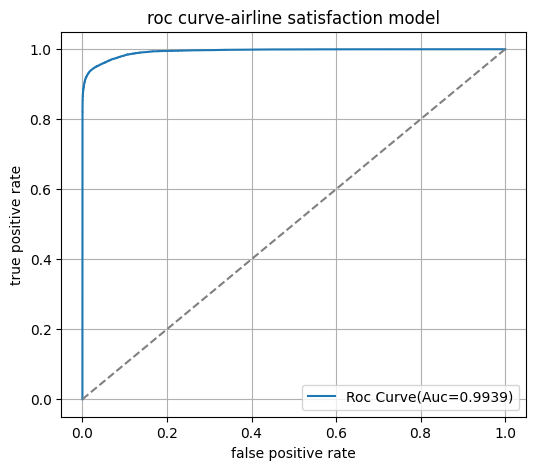

In [27]:
plt.figure(figsize=(6,5))
plt.plot(fpr,tpr,label=f"Roc Curve(Auc={roc_auc:.4f})")
plt.plot([0,1],[0,1],linestyle="--",color="gray")
plt.xlabel("false positive rate")
plt.ylabel("true positive rate")
plt.title("roc curve-airline satisfaction model")
plt.legend()
plt.grid()
plt.show()

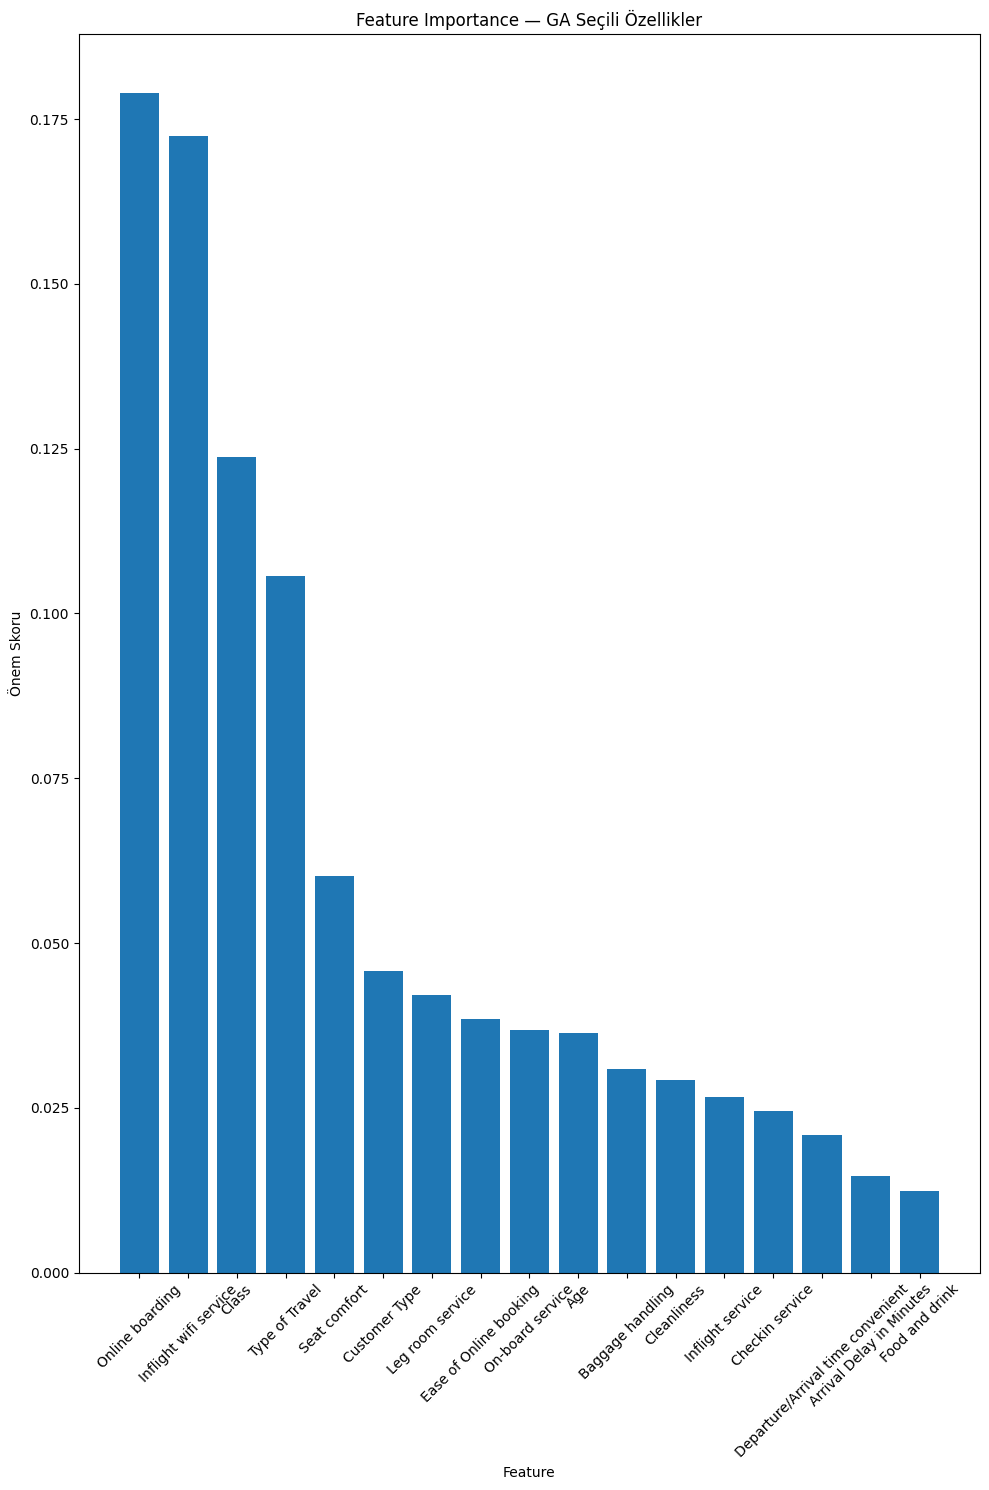

In [28]:
importances=best_model.feature_importances_
feature_names_selected=feature_names[selected_features]

indices=np.argsort(importances)[::-1]

plt.figure(figsize=(10,15))
plt.bar(range(len(importances)),importances[indices])
plt.xticks(range(len(importances)),feature_names_selected[indices],rotation=45)
plt.title('Feature Importance — GA Seçili Özellikler')
plt.xlabel('Feature')
plt.ylabel('Önem Skoru')
plt.tight_layout()
plt.show()

In [ ]:
import pickle

pickle.dump(best_model, open("model_genetic.pkl", "wb"))